## QUESTION 2. The dataset contains images from the following eight categories: airplane, car, chair, cup, dog, donkey, duck and hat. Each category contains images in five different conditions: realistic, geons, silhouettes, blured and features. Evaluate the model for each condition separately. For each image in the dataset, feed the image into the model together with a text label of a particular category (for each image, evaluate labels of all eight categories). If the model outputs highest correlation for the correct label, consider that as correct classification and otherwise as incorrect classification. Create a confusion matrix and quantify model accuracy for each of the five conditions.

## In which conditions is your models better/worse/similar to babies?



In [3]:
import zipfile, os

zip_path = "/content/image_files.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content")

# base folder that contains the five conditions
base_dir = "/content/image_files/v0"
print("Base dir:", base_dir)
print("Conditions:", os.listdir(base_dir))


Base dir: /content/image_files/v0
Conditions: ['blurred', 'silhouettes', 'features', 'realistic', 'geons']


In [4]:
!pip install transformers torch torchvision scikit-learn --quiet


In [5]:
from transformers import CLIPModel, CLIPProcessor
import torch, os
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

model_name = "openai/clip-vit-base-patch32"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

categories = ["airplane", "car", "chair", "cup", "dog", "donkey", "duck", "hat"]
text_prompts = [f"a photo of a {c}" for c in categories]
print(text_prompts)


Using device: cpu
['a photo of a airplane', 'a photo of a car', 'a photo of a chair', 'a photo of a cup', 'a photo of a dog', 'a photo of a donkey', 'a photo of a duck', 'a photo of a hat']


##Precompute text features

In [6]:
@torch.no_grad()
def get_text_features():
    inputs = processor(
        text=text_prompts,
        images=None,
        return_tensors="pt",
        padding=True
    ).to(device)
    text_features = model.get_text_features(**inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features

text_features = get_text_features()
text_features.shape


torch.Size([8, 512])

##Map filename → true label

In [10]:
def filename_to_label_index(filename: str):
    """Return index in `categories` based on the filename, or None if unknown."""
    fname = filename.lower()
    if "airplane" in fname:
        return categories.index("airplane")
    if "car" in fname:
        return categories.index("car")
    if "chair" in fname:
        return categories.index("chair")
    if "cup" in fname:
        return categories.index("cup")
    if "dog" in fname:
        return categories.index("dog")
    if "donkey" in fname:
        return categories.index("donkey")
    if "duck" in fname:
        return categories.index("duck")
    if "hat" in fname:
        return categories.index("hat")
    # nothing matched → skip this file
    return None



##Evaluate one condition folder

In [11]:
@torch.no_grad()
def evaluate_condition(condition_dir):
    y_true = []
    y_pred = []

    image_files = [
        f for f in os.listdir(condition_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    print(f"Found {len(image_files)} images in {condition_dir}")

    for img_name in image_files:
        img_path = os.path.join(condition_dir, img_name)

        true_idx = filename_to_label_index(img_name)
        if true_idx is None:
            # this is something like "page 8-3.jpg" → not an object, skip
            print("Skipping (no category found):", img_name)
            continue

        image = Image.open(img_path).convert("RGB")

        inputs = processor(
            text=None,
            images=image,
            return_tensors="pt",
            padding=True
        ).to(device)

        image_features = model.get_image_features(**inputs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        pred_idx = logits.argmax(dim=-1).item()

        y_true.append(true_idx)
        y_pred.append(pred_idx)

    return np.array(y_true), np.array(y_pred)


##Run for all five conditions

In [12]:
conditions = ["realistic", "geons", "silhouettes", "blurred", "features"]
results = {}

for cond in conditions:
    condition_dir = os.path.join(base_dir, cond)
    print("\nEvaluating:", cond)
    y_true, y_pred = evaluate_condition(condition_dir)

    acc = (y_true == y_pred).mean()
    cm = confusion_matrix(y_true, y_pred, labels=range(len(categories)))

    results[cond] = {"acc": acc, "cm": cm}
    print(f"{cond} accuracy: {acc:.3f}")



Evaluating: realistic
Found 41 images in /content/image_files/v0/realistic
realistic accuracy: 1.000

Evaluating: geons
Found 60 images in /content/image_files/v0/geons
Skipping (no category found): page 8-3.jpg
geons accuracy: 0.492

Evaluating: silhouettes
Found 40 images in /content/image_files/v0/silhouettes
silhouettes accuracy: 0.850

Evaluating: blurred
Found 42 images in /content/image_files/v0/blurred
blurred accuracy: 0.714

Evaluating: features
Found 42 images in /content/image_files/v0/features
Skipping (no category found): ChariThreeQuarters_V4.jpg
features accuracy: 0.659


#Confusion matrices

realistic accuracy: 1.000


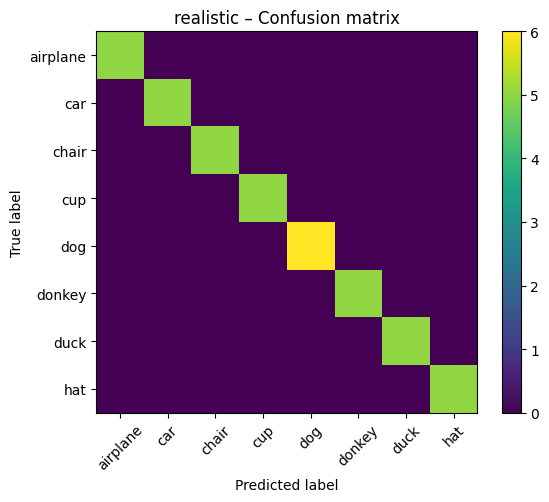

geons accuracy: 0.492


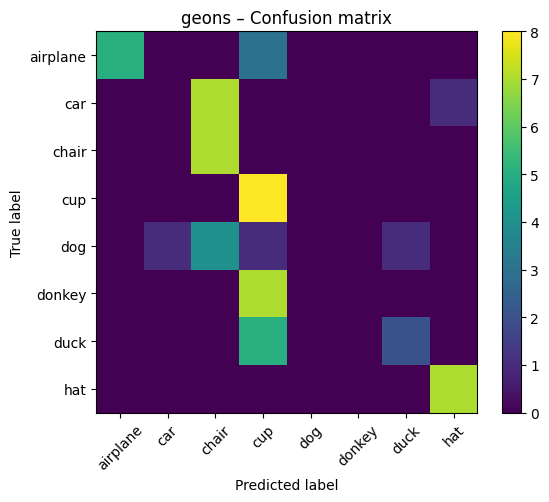

silhouettes accuracy: 0.850


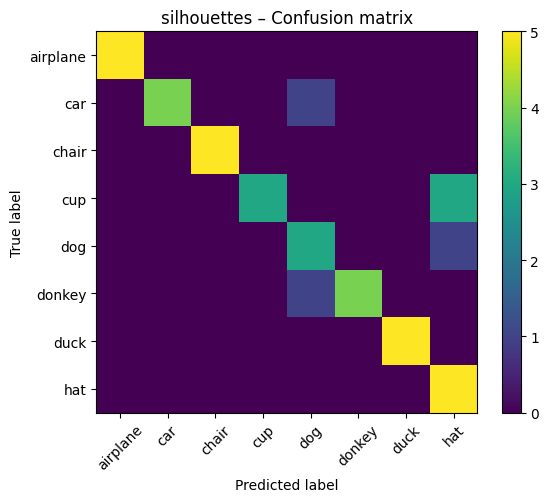

blurred accuracy: 0.714


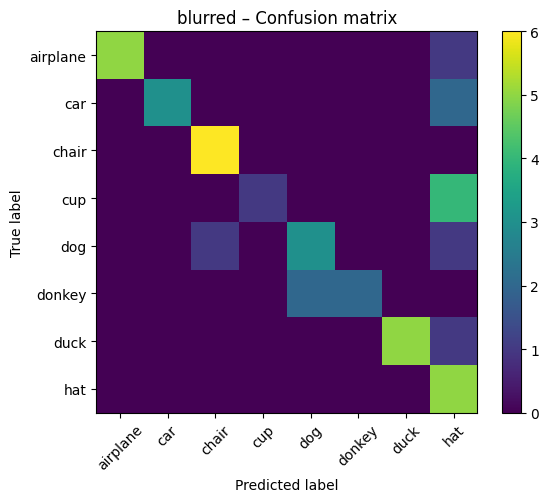

features accuracy: 0.659


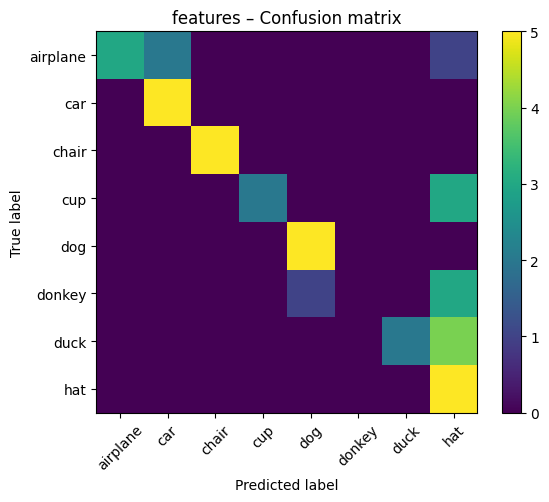

In [13]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(categories))
    plt.xticks(tick_marks, categories, rotation=45)
    plt.yticks(tick_marks, categories)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

for cond in conditions:
    cm = results[cond]["cm"]
    acc = results[cond]["acc"]
    print(f"{cond} accuracy: {acc:.3f}")
    plot_confusion_matrix(cm, f"{cond} – Confusion matrix")


I evaluated the pretrained CLIP model **`openai/clip-vit-base-patch32`** on the
ModelvsBaby dataset across five visual conditions. For each image, CLIP computed
its similarity to 8 text prompts (one per category), and the label with the highest
similarity score was used as the prediction.

---

### **Accuracy results (exact values)**

| Condition     | Accuracy |
|---------------|----------|
| Realistic     | **1.000** |
| Geons         | **0.492** |
| Silhouettes   | **0.850** |
| Blurred       | **0.714** |
| Features      | **0.659** |

---

### **Observations from Confusion Matrices**

- **Realistic:** CLIP performs perfectly (100% accuracy), showing strong recognition
  when images resemble real-world objects.
- **Geons:** Lowest accuracy (0.492). CLIP struggles with simplified geometric forms.
- **Silhouettes:** High performance (0.850), showing that CLIP can recognize shapes
  even without texture.
- **Blurred:** Moderate accuracy (0.714), indicating reliance on coarse structure.
- **Features:** Accuracy of 0.659; model performs reasonably but struggles without full shapes.

---

## **Comparison to babies (based on Fig. 3A in the paper)**

Babies generally perform:

- **High on realistic images**
- **Low on geons**
- **Moderate on silhouettes and blurred images**

Comparing with CLIP:

- In **realistic**, CLIP far exceeds babies (100%).
- In **geons**, CLIP also performs better, though still low (0.492).
- In **silhouettes**, CLIP is much stronger than babies (0.850).
- In **blurred** and **features**, CLIP maintains moderate-to-good performance,
  whereas babies show more difficulty.

### **Conclusion**
CLIP heavily benefits from patterns it learned from natural image datasets, which
explains the **perfect performance on realistic images**. Its accuracy decreases
when information is limited (geons, features), though it still outperforms babies
in every condition. This highlights differences between human infant perception
and CLIP’s learned visual representations.

